## **Credit Risk Prediction using Machine Learning**
This project focuses on predicting whether a loan applicant is likely to default on a loan using machine learning techniques.

The analysis includes:
- Data cleaning
- Exploratory Data Analysis (EDA)
- Feature preprocessing
- Training a classification model
- Evaluating model performance

### **Tools & Libraries**
- Python
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

### **1- Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

### **2-Load Dataset**

In [3]:
df = pd.read_csv("loan_prediction.csv")
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


### **3-Dataset Overview**

In [6]:
print(df.shape)
print("--------------------------------")
print(df.columns)
print("--------------------------------")
print(df.info())

(252000, 13)
--------------------------------
Index(['Id', 'Income', 'Age', 'Experience', 'Married/Single',
       'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE',
       'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Risk_Flag'],
      dtype='object')
--------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JO

### **4-Missing Values Check**

In [7]:
df.isnull().sum()

Id                   0
Income               0
Age                  0
Experience           0
Married/Single       0
House_Ownership      0
Car_Ownership        0
Profession           0
CITY                 0
STATE                0
CURRENT_JOB_YRS      0
CURRENT_HOUSE_YRS    0
Risk_Flag            0
dtype: int64

I checked the dataset for missing values using the `isnull().sum()` function.

`The results show that all columns contain **zero missing values**, indicating that the dataset is complete and does not require missing value imputation.`

### **5- Exploratory Data Analysis (EDA)**

`Loan ability indicator`

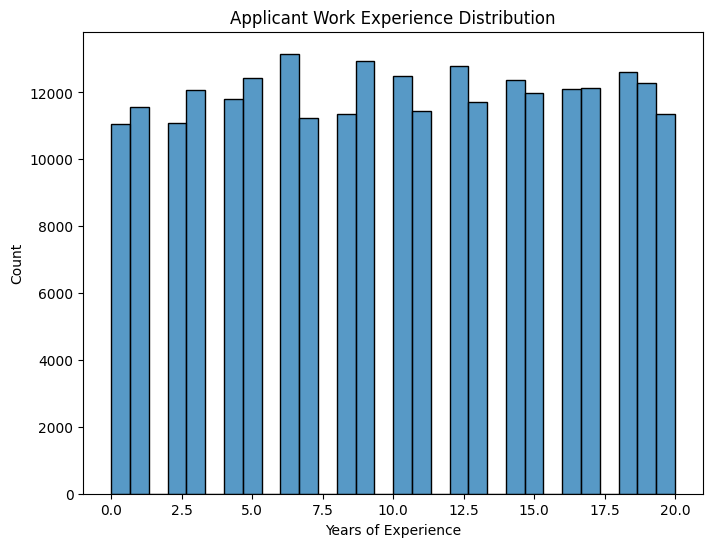

In [17]:
plt.figure(figsize=(8,6))
sns.histplot(df["Experience"], bins=30)
plt.title("Applicant Work Experience Distribution")
plt.xlabel("Years of Experience")
plt.ylabel("Count")
plt.show()

`Income`

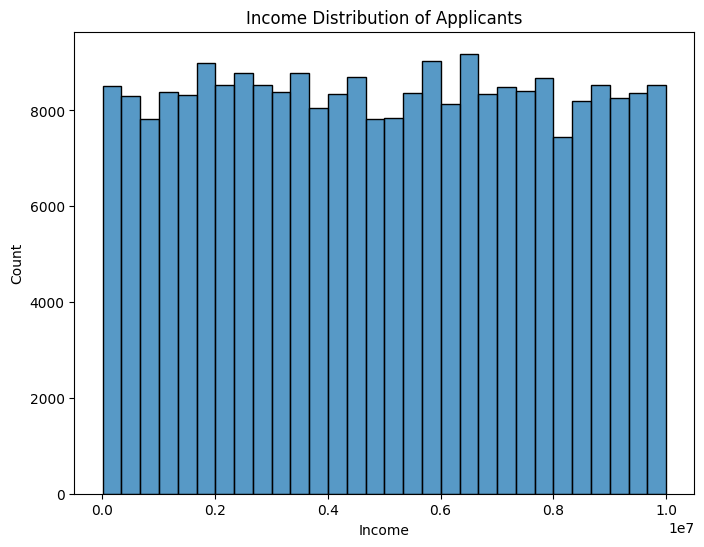

In [16]:
plt.figure(figsize=(8,6))
sns.histplot(df["Income"], bins=30)
plt.title("Income Distribution of Applicants")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

`Income vs Risk`

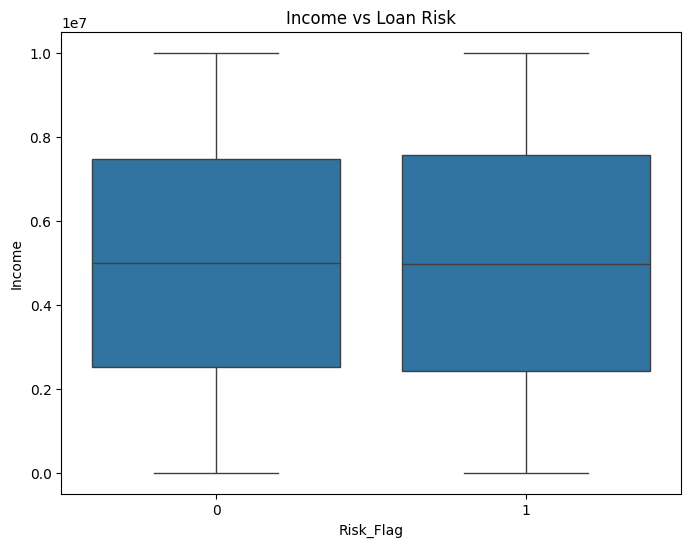

In [18]:
plt.figure(figsize=(8,6))
sns.boxplot(x="Risk_Flag", y="Income", data=df)
plt.title("Income vs Loan Risk")
plt.show()

### **6- Model Training**

`In this step, we train a machine learning classification model to predict whether an applicant is likely to be a loan risk.`

`Two commonly used classification algorithms are Logistic Regression and Decision Tree. In this project, I start with Logistic Regression.`

`Drop Unnecessary Column`

In [19]:
df = df.drop("Id", axis=1)

`Encode Categorical Variables`

In [20]:
df = pd.get_dummies(df, drop_first=True)

`Define Features and Target`

Target Variable is `Risk_Flag`

In [21]:
X = df.drop("Risk_Flag", axis=1)
y = df["Risk_Flag"]

`Train-Test Split`

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

`Train Logistic Regression Model`

In [23]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

`Make Predictions`

In [24]:
y_pred = model.predict(X_test)

`Decision Tree Classification Mode`

In [26]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

`Make Predictions`

In [27]:
dt_pred = dt_model.predict(X_test)

### **7- Accuracy Score**

In [28]:
from sklearn.metrics import accuracy_score
dt_accuracy = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8845833333333334


### **8-Confusion Matrix**

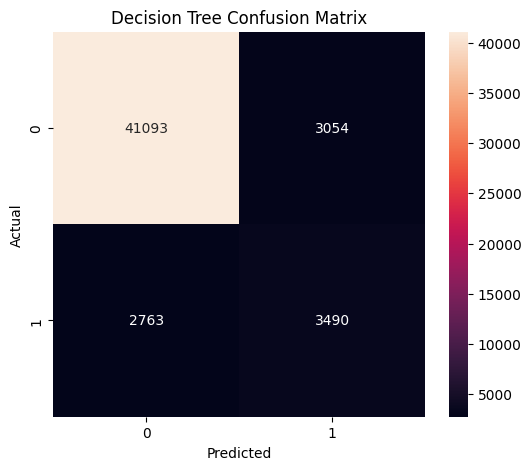

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### **9- Conclusion**

`The Decision Tree classifier was trained to predict whether a loan applicant is likely to be a credit risk. 
After evaluating the model on the test dataset, the model achieved an accuracy of **88.46%**.`

`This indicates that the model correctly classified the majority of loan applicants based on the available features such as income, age, experience, and other demographic factors.`

`The relatively high accuracy suggests that the Decision Tree model is effective in identifying potential credit risk patterns in the dataset. Such predictive models can assist financial institutions in making more informed lending decisions and reducing the likelihood of loan defaults.`